# I-ROCKET Explanation Evaluation: TSHAP + AMEE

## One Bump Dataset

This notebook compares I-ROCKET's built-in interpretability tools with
TSHAP (Le Nguyen and Ifrim, 2025) using the AMEE evaluation framework
(Nguyen et al., 2024).

**I-ROCKET** provides model-level saliency maps derived analytically
from the known kernel structure: temporal importance profiles identify
where features differ across classes, and occlusion sensitivity
measures where perturbation changes predictions.

**TSHAP** provides instance-level Shapley value attributions by
grouping timepoints into sliding windows. It is model-agnostic and
computes exact SHAP values. These are are game-theoretic measure of each timepoint's contribution to the prediction.

**AMEE** evaluates both by perturbing the most important timepoints
and measuring accuracy drop. This tells us which saliency map best
identifies the regions the classifier depends on.

References:
  Le Nguyen, T. and Ifrim, G. (2025). TSHAP: Fast and Exact SHAP
      for Explaining Time Series Classification and Regression.
      ECML-PKDD 2025.
  Nguyen, T.T., Nguyen, T.L., and Ifrim, G. (2024). Robust explainer
      recommendation for time series classification. DMKD, 38:3372-3413.

In [1]:
# Suppress OpenMP diagnostic messages that numba triggers on startup.
# These are informational only and do not affect results.
import os
os.environ["OMP_DISPLAY_ENV"] = "FALSE"
os.environ["KMP_WARNINGS"] = "0"

import numpy as np
import matplotlib.pyplot as plt
import time

RANDOM_STATE = 42

#### NOTE

This notebook depends on the tshap package: https://github.com/mlgig/tshap

Install it using pip: `!pip install tshap`

## 1. Setup: data, model, and feature selection

In [2]:
import interp_rocket as IR

In [3]:
def make_bump_data(
    n_samples=200,       # Total number of samples, split evenly between the two classes
    n_timepoints=200,    # Length of each time series
    bump_center=100,     # Center timepoint of the Gaussian bump (0-indexed)
    bump_width=20,       # Width of the bump, defined as the full width at half maximum
                         # (FWHM) of the Gaussian envelope. The standard deviation is
                         # bump_width / (2 * sqrt(2 * ln(2))) ≈ bump_width / 2.355.
    bump_amplitude=2.0,  # Peak amplitude of the bump above the noise floor
    noise_std=1.0,       # Standard deviation of the background Gaussian noise
    random_state=42      # Seed for reproducibility
):
    rng = np.random.default_rng(random_state)

    n_per_class = n_samples // 2
    n_total = n_per_class * 2  # ensure even split

    X = rng.normal(0, noise_std, size=(n_total, n_timepoints)).astype(np.float32)
    y = np.zeros(n_total, dtype=int)

    # Gaussian bump template
    t = np.arange(n_timepoints, dtype=np.float32)
    sigma = bump_width / 2.355  # FWHM to sigma
    bump = bump_amplitude * np.exp(-0.5 * ((t - bump_center) / sigma) ** 2)

    # Class 1: add bump
    y[n_per_class:] = 1
    X[n_per_class:] += bump[np.newaxis, :]

    # Shuffle
    order = rng.permutation(n_total)
    X = X[order]
    y = y[order]

    return X, y

In [4]:
X, y = make_bump_data(bump_center=100, bump_width=20, bump_amplitude=10, noise_std=2)

InterpRocket.fit: 200 instances × 200 timepoints
  Classes: [0 1]
  Fitting dilations (raw)...
  Fitting biases (raw): 3108 biases across 5 dilations...
  Fitting dilations (diff)...
  Fitting biases (diff): 3108 biases across 5 dilations...
  Transforming training data...
  Feature matrix: (200, 24864)
  Standardizing features...
  Fitting RidgeClassifierCV...
  Training accuracy: 1.0000
  Selected alpha: 0.0000
CV feature stability: 5x5 folds, tracking top 50 features per fold
  Round 1/5: 113 features appeared in every round so far
  Round 2/5: 84 features appeared in every round so far
  Round 3/5: 83 features appeared in every round so far
  Round 4/5: 75 features appeared in every round so far
  Round 5/5: 74 features appeared in every round so far

  Features in ALL folds:  4
  Features in ≥80% folds: 17
  Features in NO folds:   11908
Stable features (≥80% of 25 folds): 17


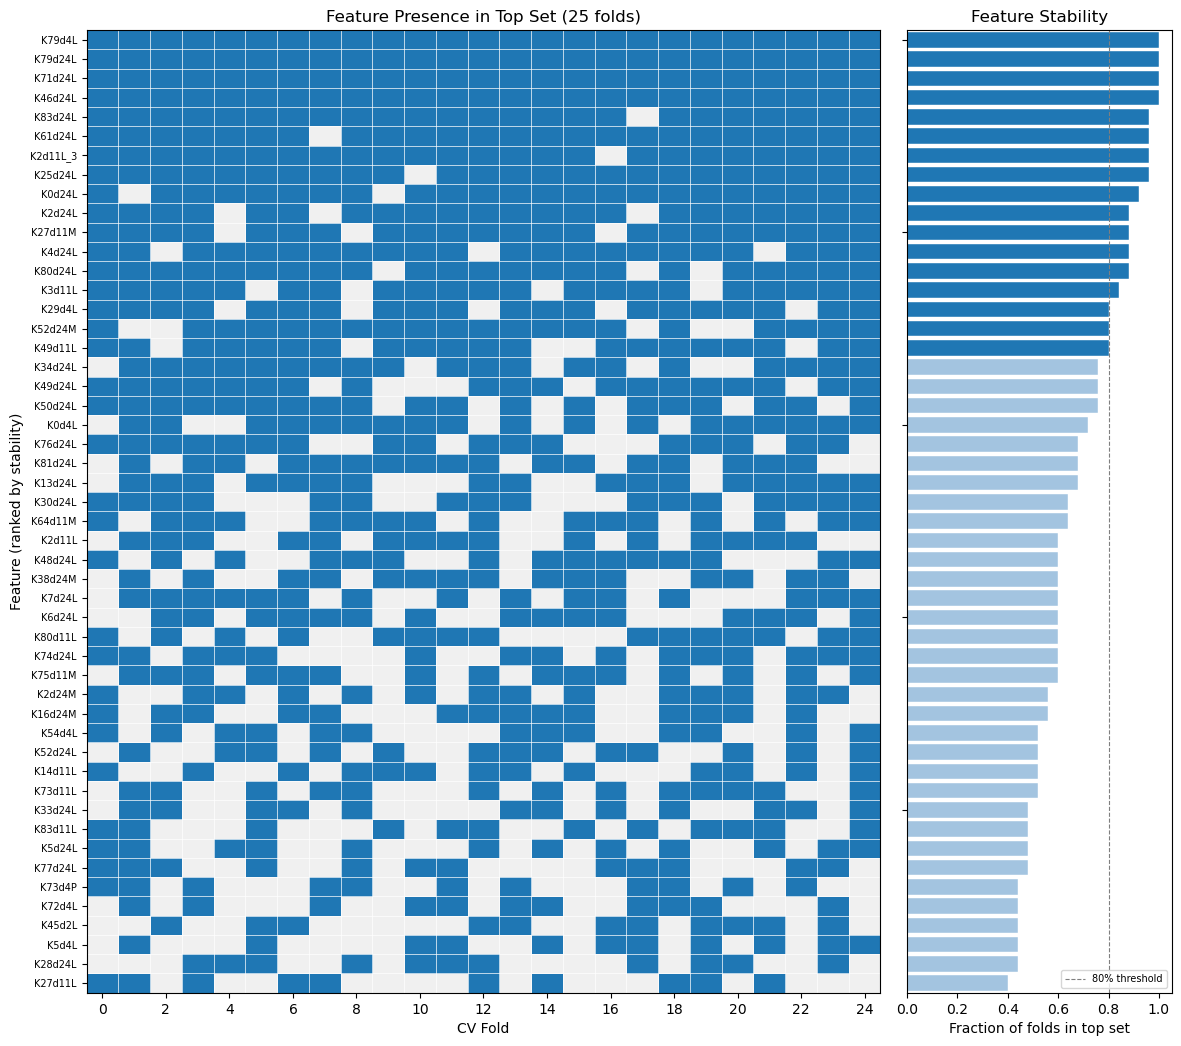

In [5]:
# Fit a reference model on all data for stability analysis
model = IR.InterpRocket(
    max_dilations_per_kernel=16,
    num_features=10000
)
model.fit(X, y)

# Feature stability analysis
stability = IR.cv_feature_stability(X, y, n_repeats=5, n_folds=5, n_top=50)
fig = IR.plot_feature_stability(stability, model=model)

stable_features = IR.get_stable_features(stability, threshold=0.8)

In [6]:
# Decode stable features and filter by dilation
low_dil_features = []
for fi in stable_features:
    info = model.decode_feature_index(int(fi))
    if info['dilation'] <= 2:  # RF <= 17 timepoints
        low_dil_features.append(fi)

low_dil_features = np.array(low_dil_features)
print(f"Stable features: {len(stable_features)}")
print(f"Low-dilation (d<=2): {len(low_dil_features)}")

Stable features: 17
Low-dilation (d<=2): 6


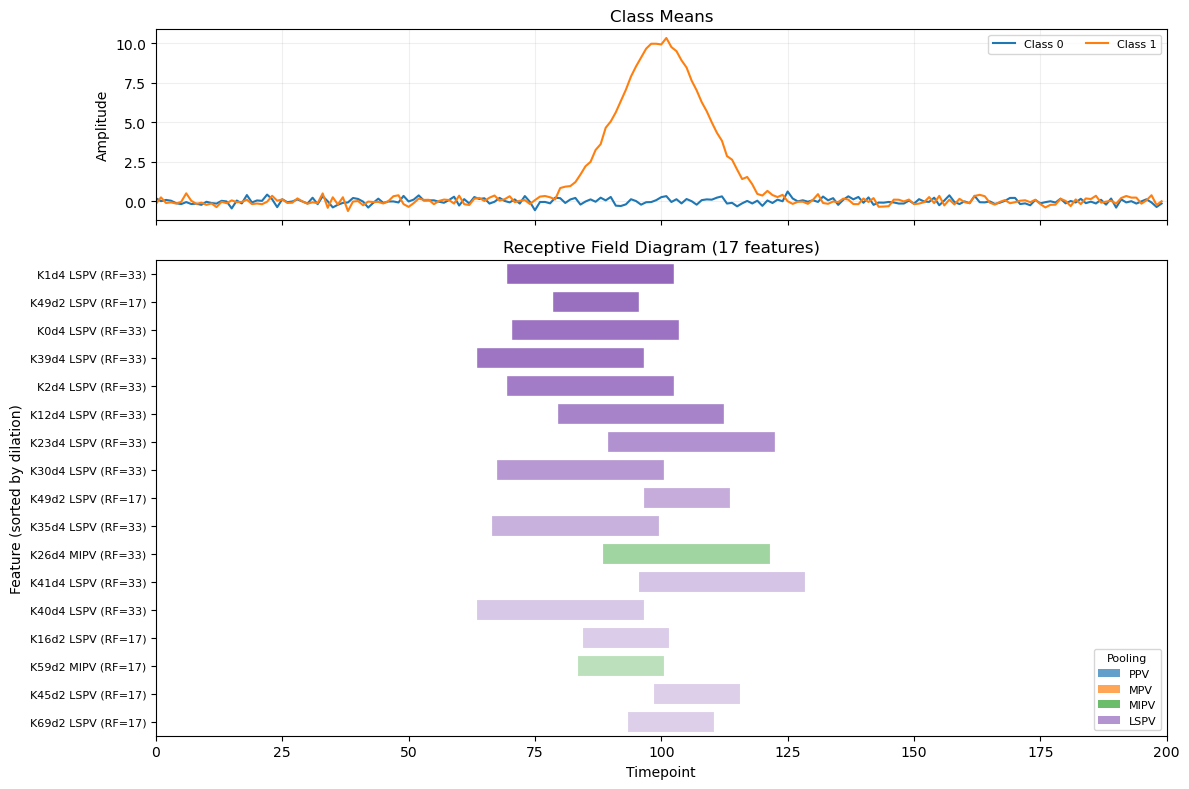

In [7]:
fig = IR.plot_receptive_field_diagram(
    model, X, y, feature_mask=stable_features
)

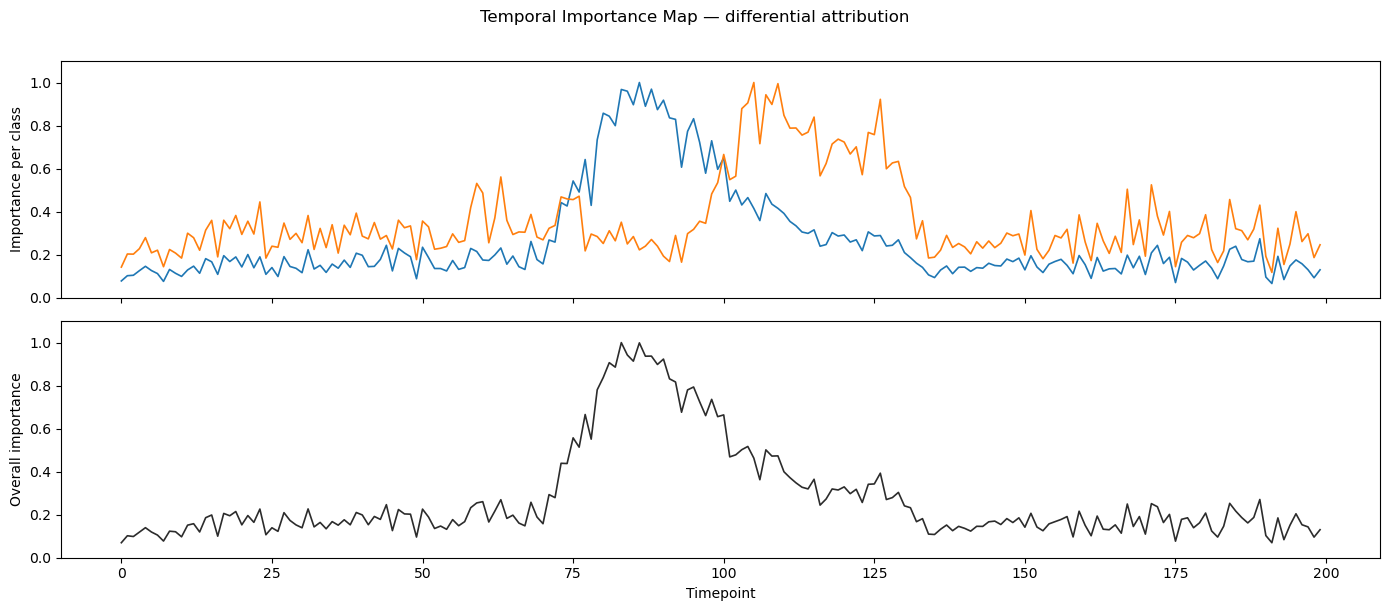

In [8]:
fig, imp_all = model.plot_temporal_importance(
    X, y, feature_mask=stable_features
)

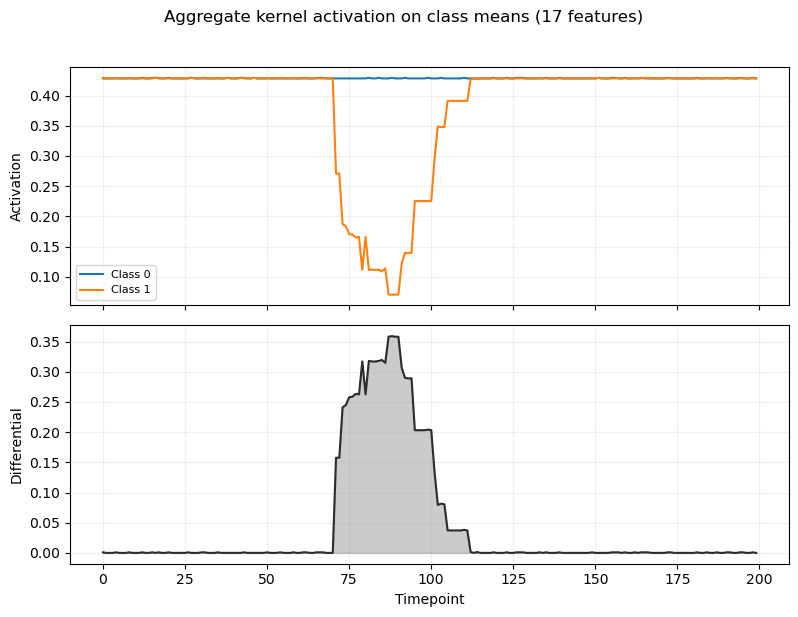

In [9]:
fig, class_act, diff = IR.plot_aggregate_activation(model, X, y,feature_mask=stable_features)

# Normalize diff output from plot_aggregate_activation to [0, 1] for AMEE
s_aggregate = np.abs(diff)
if s_aggregate.max() > 0:
    s_aggregate /= s_aggregate.max()

# COMMENT:
# The differential method in plot_temporal_importance counts how often 
# a kernel fires (binary: above or below bias), while plot_aggregate_activation 
# measures how strongly the kernel responds (continuous: the actual convolution 
# magnitude weighted by importance). On data with graded signal differences 
# across classes, the continuous version should localize better.

## 2. Extract saliency maps from all methods

We extract six saliency maps:

1. I-ROCKET temporal importance - binary activation profile comparing how often kernels fire above threshold across classes
2. I-ROCKET aggregate diff - continuous convolution magnitude on class means, weighted by feature importance
3. I-ROCKET occlusion - sliding-window perturbation measuring accuracy drop when each temporal region is masked
4. TSHAP Window - Shapley attributions computed over sliding windows
5. TSHAP ROI - Shapley attributions aggregated into contiguous regions of interest
6. Random - uniform baseline

The distinction between #1 and #2 matters: Temporal importance counts whether a kernel fires (binary, above/below bias). Aggregate diff measures how strongly the kernel responds (continuous convolution output). 

For TSHAP, we use a subset of samples for computational efficiency.

In [10]:
from amee_evaluation import (
    extract_temporal_importance,
    extract_occlusion_saliency,
    random_saliency,
    inverse_saliency,
)
from tshap_integration import extract_tshap_saliency

# --- I-ROCKET methods ---
t0 = time.time()
s_temporal = extract_temporal_importance(
    model, X, y, feature_mask=stable_features
)
t_temporal = time.time() - t0
print(f"Temporal importance: {t_temporal:.1f}s")

t0 = time.time()
s_occlusion = extract_occlusion_saliency(
    model, X, y, feature_mask=stable_features
)
t_occlusion = time.time() - t0
print(f"Occlusion: {t_occlusion:.1f}s")

# --- TSHAP ---
t0 = time.time()
tshap_results = extract_tshap_saliency(
    model, X,
    window_length=15, stride=5,
    n_background=20,
    random_state=RANDOM_STATE,
)
t_tshap = time.time() - t0
print(f"TSHAP: {t_tshap:.1f}s")

# --- Baselines ---
s_random = random_saliency(X.shape[1], random_state=RANDOM_STATE)

Temporal importance: 0.3s
Occlusion: 8.0s
TSHAP: 200 samples, window=15, stride=5, 20 background samples
  Window attr range: [-0.1608, 0.1453]
  ROI attr range: [-0.0454, 0.0459]
TSHAP: 175.0s


## 3. Visualize: I-ROCKET vs TSHAP saliency maps

Compare the five measures overlaid on class means.
I-ROCKET's temporal importance is model-level (one map for the
dataset). I-ROCKET's aggregate kernel activation 
and TSHAP attributions are instance-level, averaged here
to produce a dataset-level summary.

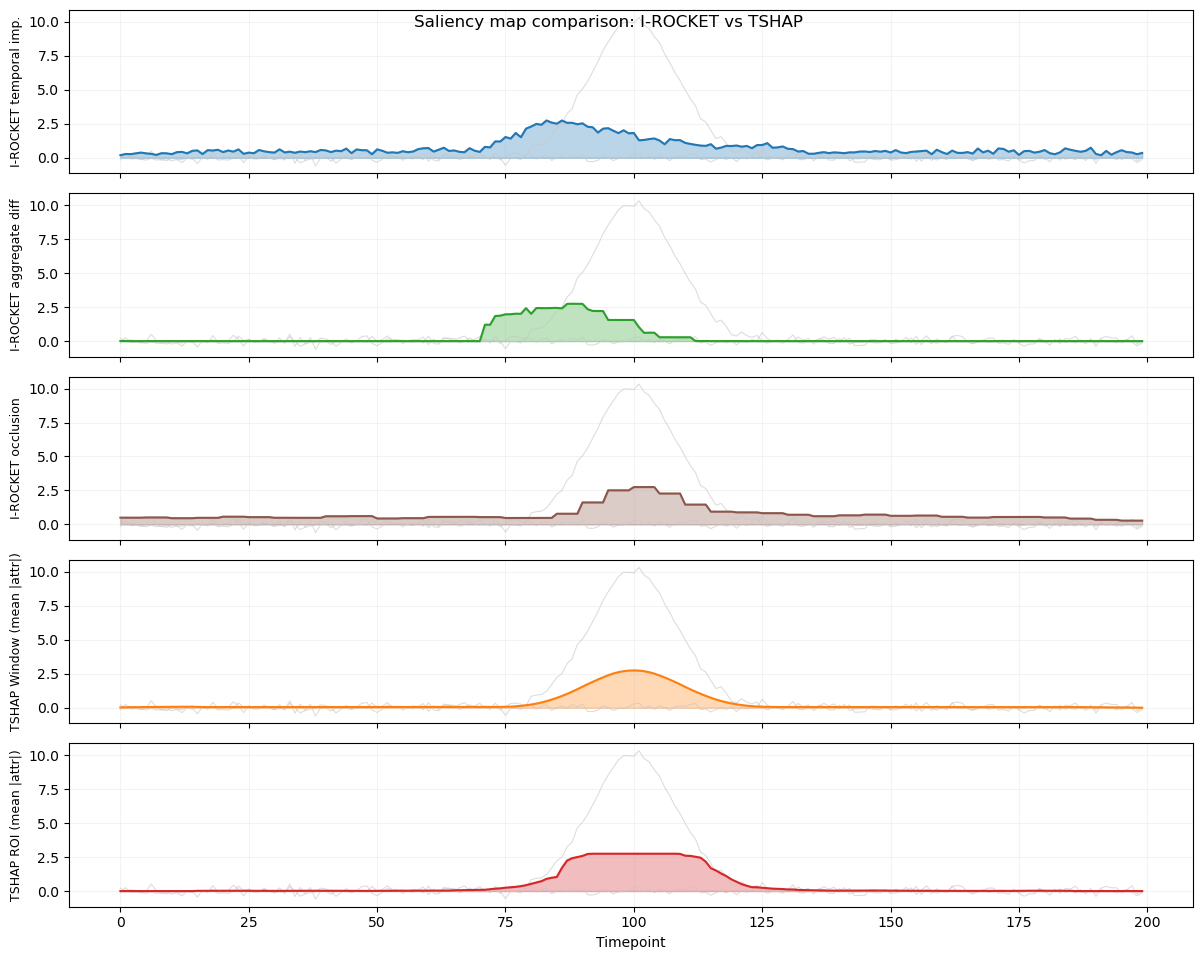

In [11]:
from tshap_integration import plot_tshap_vs_irocket

fig = plot_tshap_vs_irocket(
    X, y, tshap_results, s_temporal,
    aggregate_diff=s_aggregate,
    occlusion_saliency=s_occlusion,
)

## 4. TSHAP instance-level attributions

Unlike I-ROCKET's model-level profiles, TSHAP produces a saliency
map per instance. Red regions contribute positively to the
prediction, blue regions negatively.

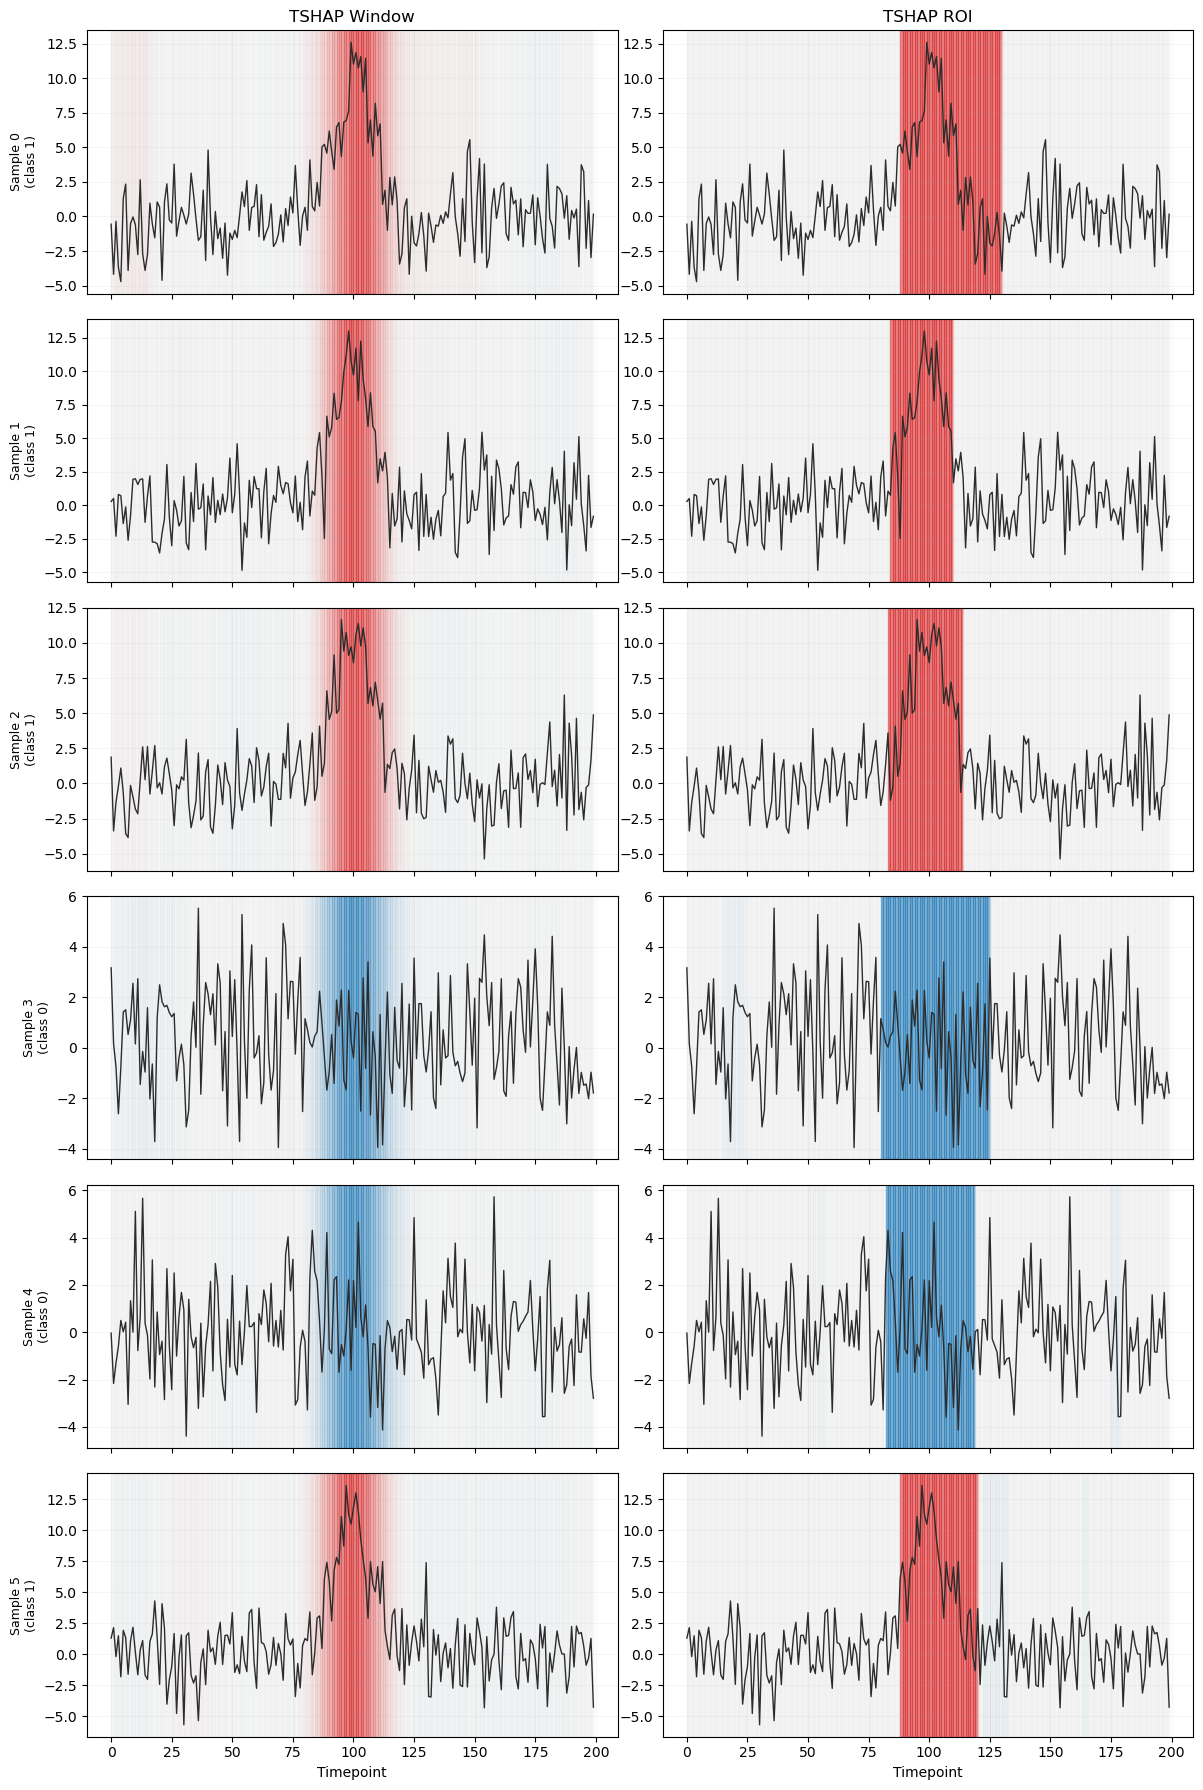

In [12]:
from tshap_integration import plot_tshap_attributions

fig = plot_tshap_attributions(X, y, tshap_results, n_show=6)

## 5. AMEE evaluation: which explainer is most informative?

We feed all five saliency maps into AMEE. For TSHAP, we use the
mean absolute attribution across instances as the dataset-level
saliency map, making it comparable with I-ROCKET's model-level
profiles.

In [13]:
from amee_evaluation import amee_evaluate, plot_amee_results

saliency_maps = {    
    "TSHAP Window": tshap_results['mean_window'],
    "TSHAP ROI": tshap_results['mean_roi'],
    "IR temporal imp.": s_temporal,
    "IR aggregate diff": s_aggregate,
    "IR occlusion": s_occlusion,
    "Random": s_random,
}

amee_results = amee_evaluate(
    model, X, y, saliency_maps,
    random_state=RANDOM_STATE,
)

               TSHAP Window + zero    : AUC drop = 0.2363
               TSHAP Window + mean    : AUC drop = 0.2353
               TSHAP Window + noise   : AUC drop = 0.2353
               TSHAP Window + inverse : AUC drop = 0.2353
                  TSHAP ROI + zero    : AUC drop = 0.2350
                  TSHAP ROI + mean    : AUC drop = 0.2340
                  TSHAP ROI + noise   : AUC drop = 0.2325
                  TSHAP ROI + inverse : AUC drop = 0.2330
           IR temporal imp. + zero    : AUC drop = 0.1875
           IR temporal imp. + mean    : AUC drop = 0.1875
           IR temporal imp. + noise   : AUC drop = 0.1875
           IR temporal imp. + inverse : AUC drop = 0.1875
          IR aggregate diff + zero    : AUC drop = 0.1750
          IR aggregate diff + mean    : AUC drop = 0.1735
          IR aggregate diff + noise   : AUC drop = 0.1650
          IR aggregate diff + inverse : AUC drop = 0.1735
               IR occlusion + zero    : AUC drop = 0.2363
              

## 6. AMEE ranking

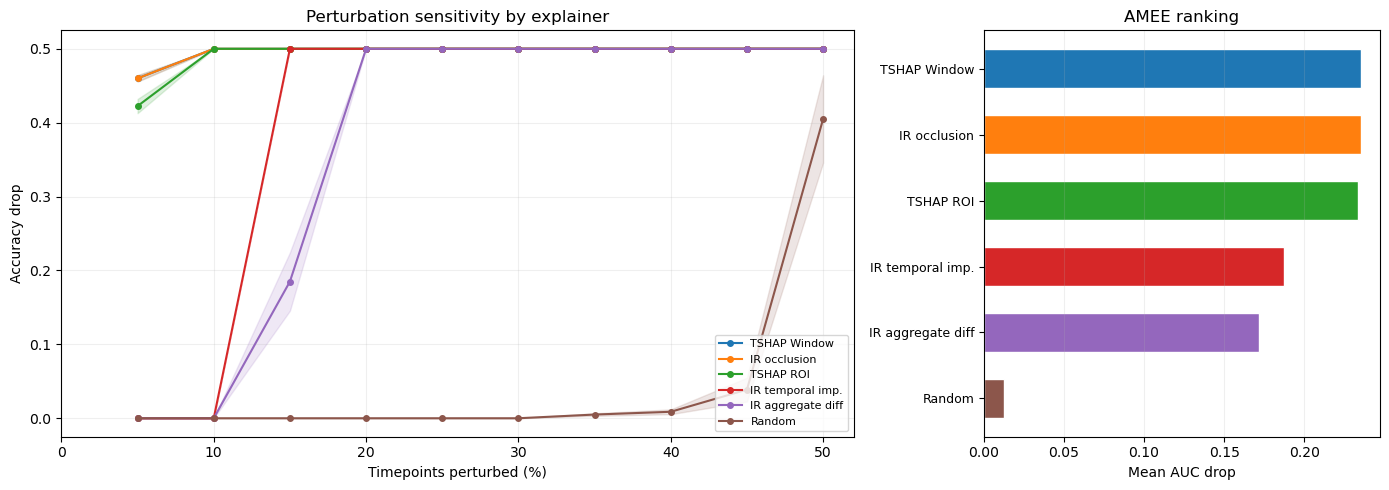

In [14]:
fig = plot_amee_results(amee_results)

## 7. Summary across perturbations

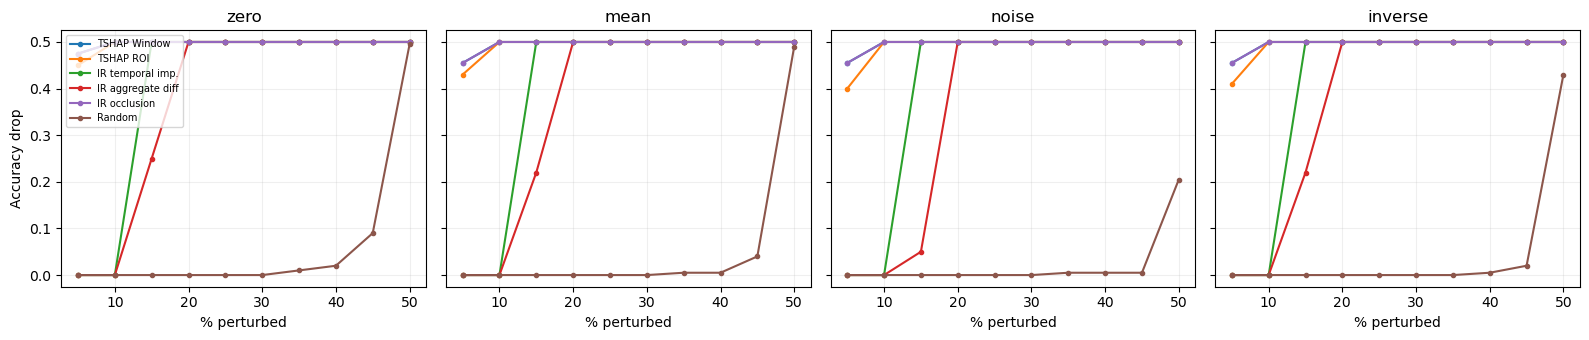

In [15]:
TAB10 = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
]

perturbations = ["zero", "mean", "noise", "inverse"]
explainer_names = list(saliency_maps.keys())

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

for ax, pert in zip(axes, perturbations):
    for i, name in enumerate(explainer_names):
        res = amee_results["per_explainer"][name][pert]
        ax.plot(
            res["fractions"] * 100,
            res["accuracy_drops"],
            color=TAB10[i],
            linewidth=1.5,
            marker="o",
            markersize=3,
            label=name if pert == "zero" else None,
        )
    ax.set_title(f"{pert}")
    ax.set_xlabel("% perturbed")
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel("Accuracy drop")
axes[0].legend(fontsize=7, loc="upper left")
plt.tight_layout()

## 8. Summary table

In [16]:
print(f"\n{'Explainer':<25s} {'Mean AUC drop':>15s} {'Rank':>6s}")
print("-" * 48)
for rank, (name, auc) in enumerate(amee_results['ranking'], 1):
    print(f"{name:<25s} {auc:>15.4f} {rank:>6d}")


Explainer                   Mean AUC drop   Rank
------------------------------------------------
TSHAP Window                       0.2355      1
IR occlusion                       0.2355      2
TSHAP ROI                          0.2336      3
IR temporal imp.                   0.1875      4
IR aggregate diff                  0.1717      5
Random                             0.0127      6


## 9. Practical advice on using these methods

Five measures are provided for understanding which timepoints matter for classification. Three come from I-ROCKET and two from the TSHAP package. 
- **Temporal importance** measures how often each kernel activates differently across classes at each timepoint.
- **Aggregate activation** measures how strongly the kernels respond at each timepoint, weighted by their importance to the classifier.
- **Occlusion analysis** measures how much accuracy drops when each time region is masked out on the input signal.
- **TSHAP Window** slides a window across the time series, computing exact Shapley values at each position.
- **TSHAP ROI** identifies contiguous regions where TSHAP Window attributions are consistently high or low and recomputes Shapley values for each region as a whole, producing sharper boundaries around the most relevant temporal epochs.

**Tradeoffs between the TSHAP measures.** As Le Nguyen and Ifrim (2025) note, TSHAP Window can spread attribution from relevant timepoints to nearby irrelevant ones, because each window position includes both relevant and irrelevant timepoints near the edge of a discriminative region, and the attribution is shared across the full window. TSHAP ROI addresses this by grouping timepoints into coherent regions before computing attributions, but its performance depends on how well the region boundaries match the true discriminative structure. In practice, TSHAP Window attributions are more consistent across datasets while ROI attributions can be sharper when the discriminative structure is well-localized.

**Recommended workflow for I-ROCKET.** Start with temporal importance and the RF diagram to understand which kernels, dilations, and time regions the classifier uses. Use aggregate activation as an alternative saliency map when the signal differences across classes are graded rather than binary. Use occlusion analysis for model-agnostic confirmation of the discriminative regions. Add TSHAP when per-instance explanations are needed (e.g., understanding why a specific trial was classified as it was) or when an independent validation of the temporal importance profile is desired. Note that I-ROCKET's built-in measures run in under a second, while TSHAP requires repeated model evaluations and scales with the number of samples, background samples, and time series length.